In [188]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [189]:
df_path = r'C:\Users\fergu\Documents\GitHub\london_sport2\data\logistic_coefficients\logistic_coef_results.csv'
df = pd.read_csv(df_path)
df = df[df['feature_names'] != 'const']
df

,feature_names,odds_ratios,pvalues,confidence_lower,confidence_upper,std_error,pseudo_rsquared,year
1,NSSEC5,0.834894,4.220772e-08,0.782724,0.890540,0.032921,0.104226,2016/17
2,Educ6,0.888683,1.070315e-11,0.858949,0.919447,0.017363,0.104226,2016/17
3,nchild,0.988780,7.545968e-01,0.921243,1.061269,0.036097,0.104226,2016/17
4,nadult,0.954628,1.608339e-01,0.894640,1.018639,0.033113,0.104226,2016/17
5,VolAny,1.548191,3.216757e-11,1.360698,1.761519,0.065863,0.104226,2016/17
...,...,...,...,...,...,...,...,...
358,HHLiv12_8.0,0.980272,9.475409e-01,0.541471,1.774672,0.302832,0.110339,2022/23
359,HHLiv12_9.0,0.827478,4.429749e-01,0.510086,1.342361,0.246843,0.110339,2022/23
360,HHLiv12_10.0,0.818488,1.225250e-01,0.634759,1.055398,0.129703,0.110339,2022/23
361,HHLiv12_11.0,0.709000,2.056585e-02,0.529962,0.948522,0.148498,0.110339,2022/23


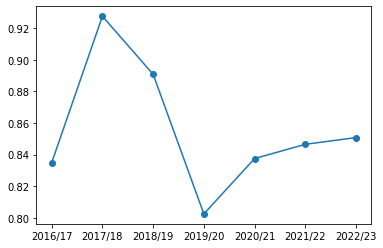

In [190]:
nssec = df[df['feature_names'] == 'NSSEC5']
plt.plot(nssec['year'], nssec['odds_ratios'], marker='o')

In [191]:
for idx, name in enumerate(sorted(list(df['feature_names'].unique()))):
    print(idx, name)

0 Age9_3.0
1 Age9_4.0
2 Age9_5.0
3 Age9_6.0
4 Age9_7.0
5 Disab3_2.0
6 Disab3_3.0
7 Educ6
8 Eth7_2.0
9 Eth7_3.0
10 Eth7_4.0
11 Eth7_5.0
12 Eth7_6.0
13 Eth7_7.0
14 Gend3_2.0
15 Gend3_3.0
16 HHLiv12_10.0
17 HHLiv12_11.0
18 HHLiv12_12.0
19 HHLiv12_2.0
20 HHLiv12_3.0
21 HHLiv12_4.0
22 HHLiv12_5.0
23 HHLiv12_6.0
24 HHLiv12_7.0
25 HHLiv12_8.0
26 HHLiv12_9.0
27 IMD10_10.0
28 IMD10_2.0
29 IMD10_3.0
30 IMD10_4.0
31 IMD10_5.0
32 IMD10_6.0
33 IMD10_7.0
34 IMD10_8.0
35 IMD10_9.0
36 Motiva_POP
37 NSSEC5
38 VolAny
39 WorkStat10_10.0
40 WorkStat10_2.0
41 WorkStat10_3.0
42 WorkStat10_4.0
43 WorkStat10_5.0
44 WorkStat10_6.0
45 WorkStat10_7.0
46 WorkStat10_8.0
47 WorkStat10_9.0
48 motivd_POP
49 nadult
50 nchild


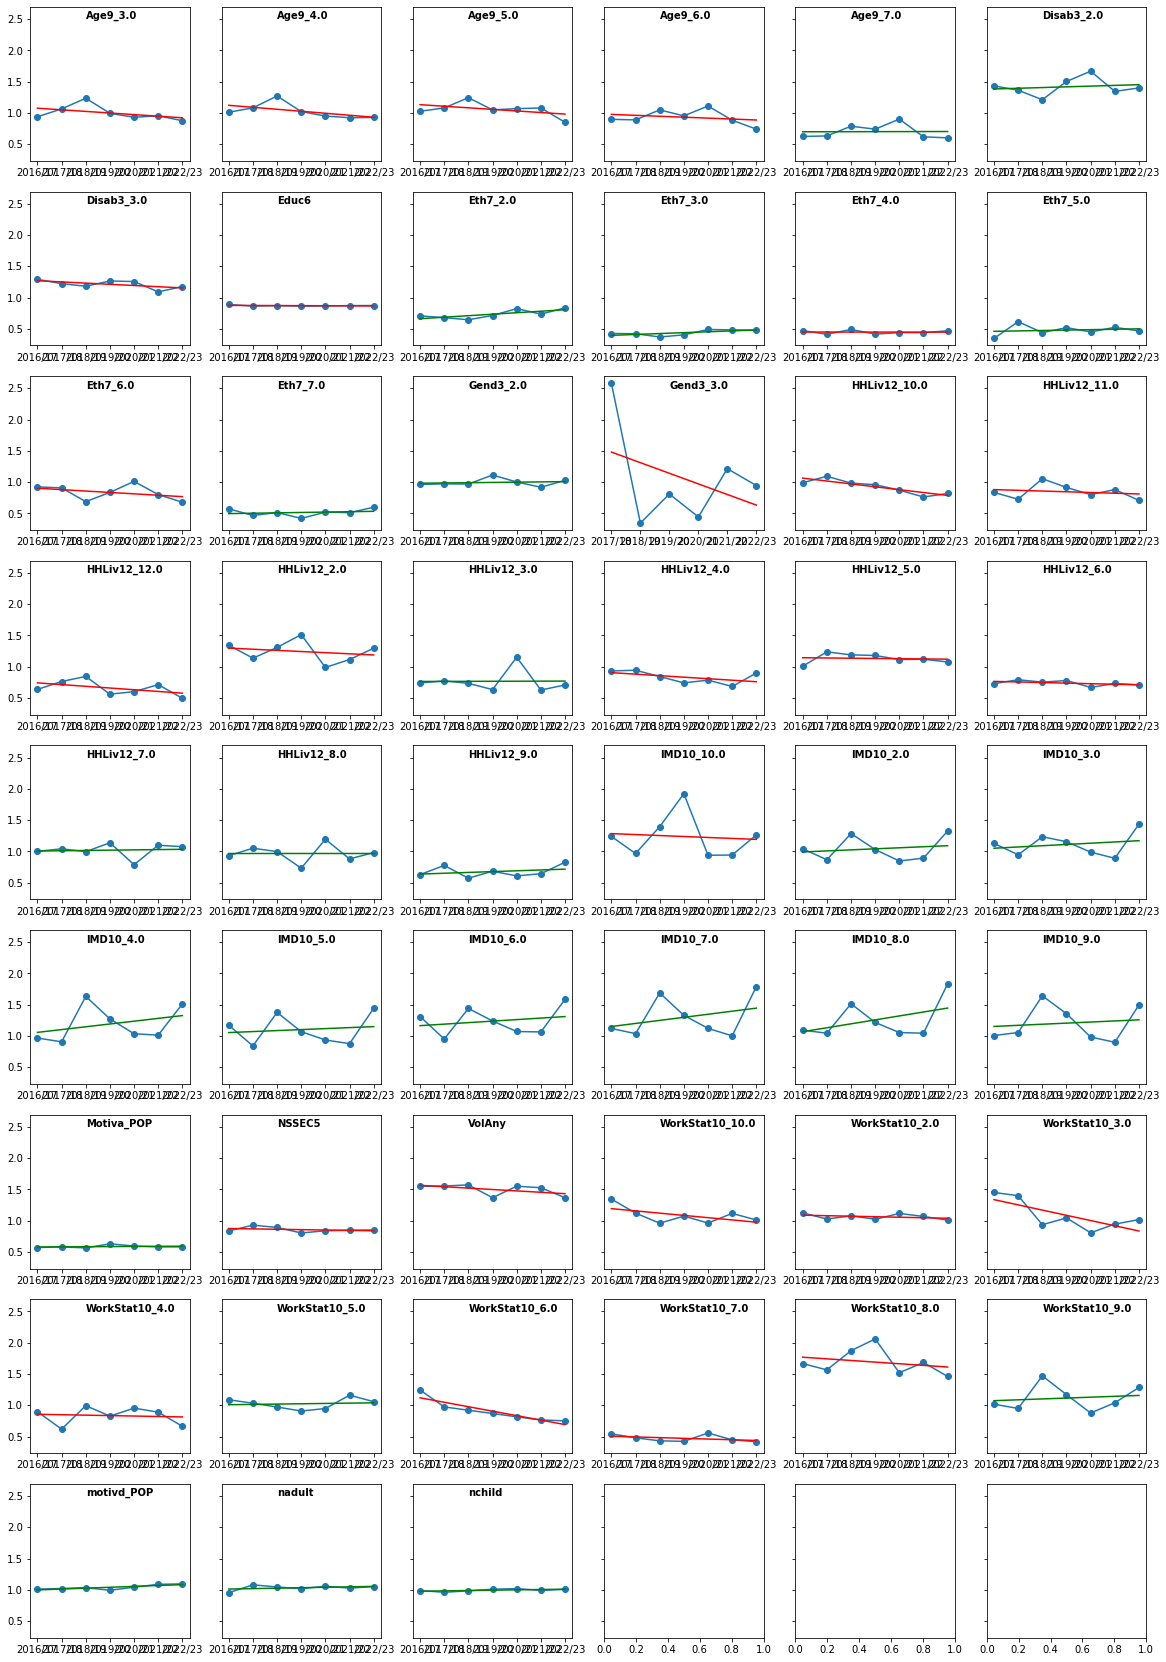

In [ ]:
fig, axes = plt.subplots(9,6 , figsize=(20,3*10), sharey=True)
axes = axes.flatten()
for idx, name in enumerate(sorted(list(df['feature_names'].unique()))):
    trend_colour = ''
    new = df[df['feature_names'] == name]
    coef = np.polyfit(np.arange(len(new['year'])), new['odds_ratios'], deg=1)
    trend = np.poly1d(coef)
    if coef[0] > 0:
        trend_colour = 'green'
    else:
        trend_colour = 'red'
    axes[idx].plot(new['year'], new['odds_ratios'], marker='o')
    axes[idx].plot(new['year'], trend(np.arange(len(new['year']))), c=trend_colour)
    axes[idx].text(2, 2.5, name, weight='bold')
    

In [193]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [194]:
new = df[['feature_names', 'year', 'odds_ratios']]
new = new[new['feature_names'] == 'Eth7_6.0']
# model = ARIMA()
data = new['odds_ratios'].values
data

array([0.92411089, 0.90809994, 0.68886926, 0.83530753, 1.01160081,
       0.80105464, 0.67864364])

In [195]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
simpexp = SimpleExpSmoothing(data)
exp = ExponentialSmoothing(data)
holt = Holt(data, damped_trend=True)
simp_fit = simpexp.fit()
exp_fit = exp.fit()
holt_fit = holt.fit()

In [196]:
holt_preds = holt_fit.forecast(len(data))
simp_preds = simp_fit.forecast(len(data))
exp_preds = exp_fit.forecast(len(data))

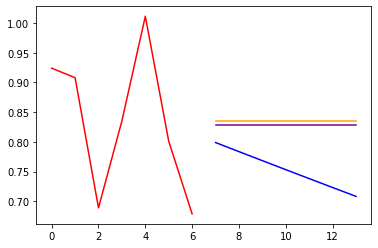

In [197]:
data_len = np.arange(len(data))
pred_len = np.arange(len(data), len(data) + len(holt_preds))
plt.plot(data_len, data, c='red')
plt.plot(pred_len, holt_preds, c='blue')
plt.plot(pred_len, simp_preds, c='purple')
plt.plot(pred_len, exp_preds, c='orange')

In [198]:
print(f'Holt:\n{holt_fit.params}')
print(f'EXP:\n {exp_fit.params}')
print(f'Simp EXP:\n {simp_fit.params}')

Holt:
{'smoothing_level': np.float64(1.4901161193847656e-08), 'smoothing_trend': np.float64(1.4901161193847656e-08), 'smoothing_seasonal': np.float64(nan), 'damping_trend': np.float64(0.995), 'initial_level': np.float64(0.9241108850245096), 'initial_trend': np.float64(-0.016010947633291917), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
EXP:
 {'smoothing_level': np.float64(1.4901161193847656e-08), 'smoothing_trend': np.float64(nan), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(0.8353838095471544), 'initial_trend': np.float64(nan), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}
Simp EXP:
 {'smoothing_level': np.float64(0.23238751117558465), 'smoothing_trend': np.float64(nan), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(0.9241108850245096), 'initial_trend': np.float64(nan), 'initial_season